# Predição valor_pago

In [2]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score,
)
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge, ElasticNet, Lasso, SGDRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    HistGradientBoostingRegressor,
    AdaBoostRegressor,
)
from sklearn.neural_network import MLPRegressor

from xgboost import XGBRegressor
from catboost import CatBoostRegressor, Pool
# from lightgbm import LGBMRegressor

from sklearn.model_selection import RandomizedSearchCV
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

Usando os dados enriquecidos com o capes:
1. foi utilizado uma sample de 10000 para acelerar o processso
2. usado um quantil de 0.95, totalizando um teto de R$ 33 mil reais (outliers)

In [3]:
ARQUIVO_PARQUET = "dados/cnpq_com_capes.parquet"
TARGET = "valor_pago"

print("\nCarregando dataset...")
df = pd.read_parquet(ARQUIVO_PARQUET)
print("Shape original:", df.shape)


df = df.sample(n=10000, random_state=42)
print("Shape após amostragem:", df.shape)

df = df.drop(columns=['_record_number'])

teto = pd.to_numeric(df[TARGET], errors='coerce').quantile(0.95)
df = df[pd.to_numeric(df[TARGET], errors='coerce') <= teto].copy()
print(f"Teto (p95): R$ {teto:,.2f}  |  Shape após corte: {df.shape}")


Carregando dataset...
Shape original: (3274778, 28)
Shape após amostragem: (10000, 28)
Teto (p95): R$ 33,473.61  |  Shape após corte: (9500, 27)


In [4]:
resultados = []

No treino foi usado:
1. 70% treino 
2. 15% validação
3. 15% teste

In [5]:

y_raw = pd.to_numeric(df[TARGET], errors='coerce')
X = df.drop(columns=[TARGET])

# Remove linhas sem target
valid_mask = y_raw.notna()
X = X.loc[valid_mask]
y_raw = y_raw.loc[valid_mask]

# Colunas categóricas
cat_cols = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()
for col in cat_cols:
    X[col] = X[col].fillna("nulo").astype(str)

# Colunas numéricas
num_cols = [c for c in X.columns if c not in cat_cols]
for col in num_cols:
    X[col] = X[col].fillna(0)

# Split: 70% treino, 15% validação, 15% teste

X_train, X_temp, y_train_raw, y_temp_raw = train_test_split(
    X, y_raw, test_size=0.30, random_state=42
)
X_valid, X_test, y_valid_raw, y_test_raw = train_test_split(
    X_temp, y_temp_raw, test_size=0.50, random_state=42
)


y_train = np.log1p(y_train_raw.values)
y_valid = np.log1p(y_valid_raw.values)
y_test  = np.log1p(y_test_raw.values)

print("Treino:", X_train.shape)
print("Validação:", X_valid.shape)
print("Teste:", X_test.shape)

Treino: (6650, 26)
Validação: (1425, 26)
Teste: (1425, 26)


1. Foi usado a biblioteca do Optuna para otimização de hiperparâmetros
2. O modelo escolhido foi o CatBoostRegressor, que é um modelo de boosting eficiente e que lida bem com dados categóricos
3. O processo de otimização envolveu a definição de um espaço de busca para os hiperparâmetros do modelo
4. Métricas: MAE, RMSEM, R² e R² log

In [ ]:
from lightgbm import LGBMRegressor
from sklearn.svm import SVR


def objective_catboost(trial):
    model = CatBoostRegressor(
        iterations=trial.suggest_int("iterations", 500, 3000),
        depth=trial.suggest_int("depth", 4, 10),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        l2_leaf_reg=trial.suggest_float("l2_leaf_reg", 1, 20),
        random_strength=trial.suggest_float("random_strength", 0, 10),
        bagging_temperature=trial.suggest_float("bagging_temperature", 0, 5),
        loss_function="RMSE",
        verbose=False,
        random_seed=42,
        thread_count=-1,
        allow_writing_files=False,
    )

    model.fit(
        X_train, y_train,
        cat_features=cat_cols,
        eval_set=(X_valid, y_valid),
        early_stopping_rounds=50,
        verbose=False,
    )

    pred_valid = model.predict(X_valid)
    return np.sqrt(mean_squared_error(y_valid, pred_valid))


# CORRIGIDO: cada study salvo em variável própria
study_cat = optuna.create_study(direction="minimize")
study_cat.optimize(objective_catboost, n_trials=30, n_jobs=1)

print("CatBoost — Melhor RMSE (val, log):", study_cat.best_value)
print("Melhores parâmetros:", study_cat.best_params)

resultados.append({
    "Modelo": "CatBoost",
    "RMSE_val_log": study_cat.best_value,
})


def objective_xgboost(trial):
    model = XGBRegressor(
        n_estimators=trial.suggest_int("n_estimators", 500, 3000),
        max_depth=trial.suggest_int("max_depth", 4, 10),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        reg_alpha=trial.suggest_float("reg_alpha", 0, 10),
        reg_lambda=trial.suggest_float("reg_lambda", 0, 10),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
        random_state=42,
        n_jobs=-1,
        early_stopping_rounds=50,
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_valid, y_valid)],
        verbose=False,
    )

    pred_valid = model.predict(X_valid)
    return np.sqrt(mean_squared_error(y_valid, pred_valid))


# CORRIGIDO: study_xgb separado
study_xgb = optuna.create_study(direction="minimize")
study_xgb.optimize(objective_xgboost, n_trials=30, n_jobs=1)

print("XGBoost — Melhor RMSE (val, log):", study_xgb.best_value)
print("Melhores parâmetros:", study_xgb.best_params)

resultados.append({
    "Modelo": "XGBoost",
    "RMSE_val_log": study_xgb.best_value,
})


def objective_lightgbm(trial):
    model = LGBMRegressor(
        n_estimators=trial.suggest_int("n_estimators", 500, 3000),
        max_depth=trial.suggest_int("max_depth", 4, 10),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        reg_alpha=trial.suggest_float("reg_alpha", 0, 10),
        reg_lambda=trial.suggest_float("reg_lambda", 0, 10),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
        random_state=42,
        n_jobs=-1,
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_valid, y_valid)],
        callbacks=[
            __import__('lightgbm').early_stopping(50, verbose=False),
            __import__('lightgbm').log_evaluation(period=-1),
        ],
    )

    pred_valid = model.predict(X_valid)
    return np.sqrt(mean_squared_error(y_valid, pred_valid))


# CORRIGIDO: study_lgbm separado
study_lgbm = optuna.create_study(direction="minimize")
study_lgbm.optimize(objective_lightgbm, n_trials=30, n_jobs=1)

print("LightGBM — Melhor RMSE (val, log):", study_lgbm.best_value)
print("Melhores parâmetros:", study_lgbm.best_params)

resultados.append({
    "Modelo": "LightGBM",
    "RMSE_val_log": study_lgbm.best_value,
})


def objective_svm(trial):
    model = SVR(
        kernel=trial.suggest_categorical("kernel", ["rbf", "linear", "poly"]),
        C=trial.suggest_float("C", 0.1, 100, log=True),
        gamma=trial.suggest_float("gamma", 0.001, 1, log=True),
    )

    model.fit(X_train, y_train)
    pred_valid = model.predict(X_valid)
    return np.sqrt(mean_squared_error(y_valid, pred_valid))


# CORRIGIDO: study_svm separado
study_svm = optuna.create_study(direction="minimize")
study_svm.optimize(objective_svm, n_trials=30, n_jobs=1)

print("SVM — Melhor RMSE (val, log):", study_svm.best_value)
print("Melhores parâmetros:", study_svm.best_params)

resultados.append({
    "Modelo": "SVM",
    "RMSE_val_log": study_svm.best_value,
})


[W 2026-06-02 15:37:07,177] Trial 0 failed with parameters: {'n_estimators': 1692, 'max_depth': 10, 'learning_rate': 0.09190333996405715, 'reg_alpha': 2.7096458236129806, 'reg_lambda': 0.8368978911805303, 'subsample': 0.9880918559868419, 'colsample_bytree': 0.6739994771058038} because of the following error: TypeError("XGBModel.fit() got an unexpected keyword argument 'early_stopping_rounds'").
Traceback (most recent call last):
  File "c:\Users\felip\Documents\predicao-cnpq\env\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\felip\AppData\Local\Temp\ipykernel_9640\1200088193.py", line 58, in objective_xgboost
    model.fit(
    ~~~~~~~~~^
        X_train, y_train,
        ^^^^^^^^^^^^^^^^^
    ...<2 lines>...
        verbose=False,
        ^^^^^^^^^^^^^^
    )
    ^
  File "c:\Users\felip\Documents\predicao-cnpq\env\Lib\site-packages\xgboost\core.py", line 751, in inner_f
    return func(**kwargs)
TypeError: XGBM

CatBoost — Melhor RMSE (val, log): 0.7275780669156346
Melhores parâmetros: {'iterations': 2737, 'depth': 9, 'learning_rate': 0.04505707239518666, 'l2_leaf_reg': 2.090062789862316, 'random_strength': 3.821888925629425, 'bagging_temperature': 2.105943041606822}


TypeError: XGBModel.fit() got an unexpected keyword argument 'early_stopping_rounds'

In [ ]:
X_trainval = pd.concat([X_train, X_valid])
y_trainval  = np.concatenate([y_train, y_valid])

# ── CatBoost ──────────────────────────────────────────────
# CORRIGIDO: usa study_cat.best_params (não sobrescrito)
best_model = CatBoostRegressor(
    **study_cat.best_params,
    loss_function="RMSE",
    random_seed=42,
    thread_count=-1,
    allow_writing_files=False,
    verbose=100,
)
best_model.fit(X_trainval, y_trainval, cat_features=cat_cols)

# ── XGBoost ───────────────────────────────────────────────
# CORRIGIDO: usa study_xgb.best_params
best_model_xgb = XGBRegressor(
    **study_xgb.best_params,
    random_state=42,
    n_jobs=-1,
)
best_model_xgb.fit(X_trainval, y_trainval)

# ── LightGBM ──────────────────────────────────────────────
# CORRIGIDO: usa study_lgbm.best_params + typo X_trainval corrigido
best_model_lgbm = LGBMRegressor(
    **study_lgbm.best_params,
    random_state=42,
    n_jobs=-1,
)
best_model_lgbm.fit(X_trainval, y_trainval)

# ── SVM ───────────────────────────────────────────────────
# CORRIGIDO: usa study_svm.best_params
best_model_svm = SVR(**study_svm.best_params)
best_model_svm.fit(X_trainval, y_trainval)

# ── Previsões no conjunto de TESTE ────────────────────────
pred_log      = best_model.predict(X_test)
pred_real     = np.expm1(pred_log)
y_real        = np.expm1(y_test)

pred_log_xgb  = best_model_xgb.predict(X_test)
pred_real_xgb = np.expm1(pred_log_xgb)

pred_log_lgbm  = best_model_lgbm.predict(X_test)
pred_real_lgbm = np.expm1(pred_log_lgbm)

pred_log_svm  = best_model_svm.predict(X_test)
pred_real_svm = np.expm1(pred_log_svm)


In [ ]:
def print_metrics(nome, y_real, pred_real, y_log, pred_log):
    mae  = mean_absolute_error(y_real, pred_real)
    rmse = root_mean_squared_error(y_real, pred_real)
    r2r  = r2_score(y_real, pred_real)
    r2l  = r2_score(y_log,  pred_log)
    print(f"\n── {nome} ──────────────────────────────")
    print(f"MAE     : {mae:,.2f}")
    print(f"RMSE    : {rmse:,.2f}")
    print(f"R² real : {r2r:.4f}")
    print(f"R² log  : {r2l:.4f}")

print(f"\n===== RESULTADOS (conjunto de teste) =====")
print(f"Escopo do modelo: bolsas até R$ {teto:,.2f} (p95)")

print_metrics("CatBoost",  y_real, pred_real,      y_test, pred_log)
print_metrics("XGBoost",   y_real, pred_real_xgb,  y_test, pred_log_xgb)
print_metrics("LightGBM",  y_real, pred_real_lgbm, y_test, pred_log_lgbm)
print_metrics("SVM",       y_real, pred_real_svm,  y_test, pred_log_svm)


MAE     : 3,376.96
RMSE    : 5,774.89
R² real : 0.4947
R² log  : 0.6587

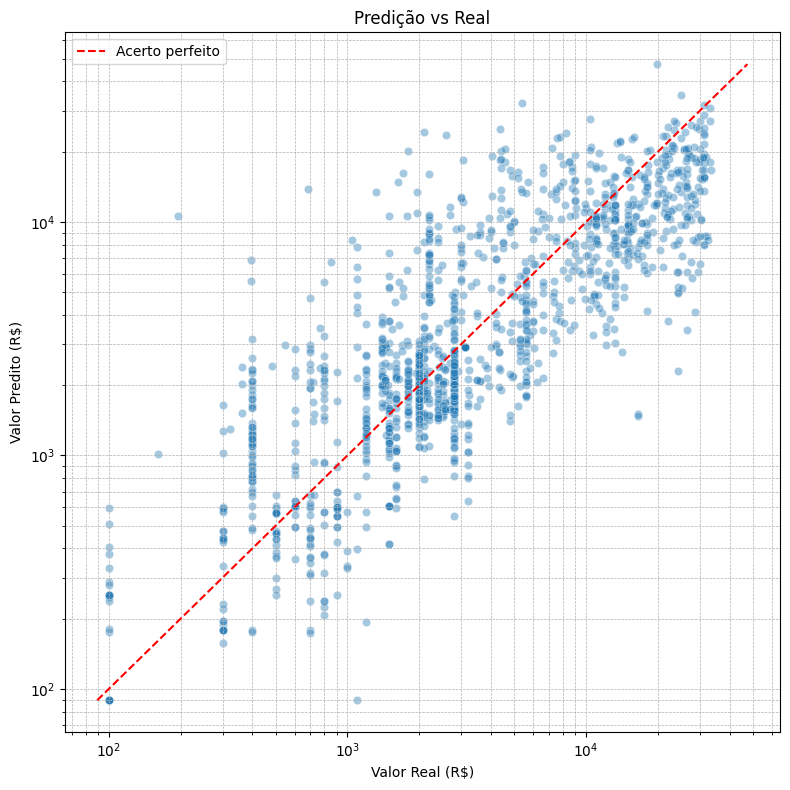

In [ ]:

# GRÁFICO — Predição vs Real
plt.figure(figsize=(8, 8))
sns.scatterplot(x=y_real, y=pred_real, alpha=0.4)

lims = [min(y_real.min(), pred_real.min()), max(y_real.max(), pred_real.max())]
plt.plot(lims, lims, 'r--', label='Acerto perfeito')

plt.xlabel("Valor Real (R$)")
plt.ylabel("Valor Predito (R$)")
plt.title("Predição vs Real")
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.tight_layout()
plt.show()

   decile  count           MAE          RMSE
0       0  152.0    662.791756   1339.887913
1       1  137.0   1068.020338   1968.053284
2       2  152.0   1342.357687   2903.213027
3       3  145.0    775.355811   2385.085781
4       4  208.0   1702.183934   2967.516545
5       5   61.0   2849.150570   4010.026352
6       6  142.0   3944.489398   5782.951990
7       7  144.0   4416.679845   5578.914033
8       8  141.0   5932.666349   7000.845846
9       9  143.0  11805.294298  13395.350592


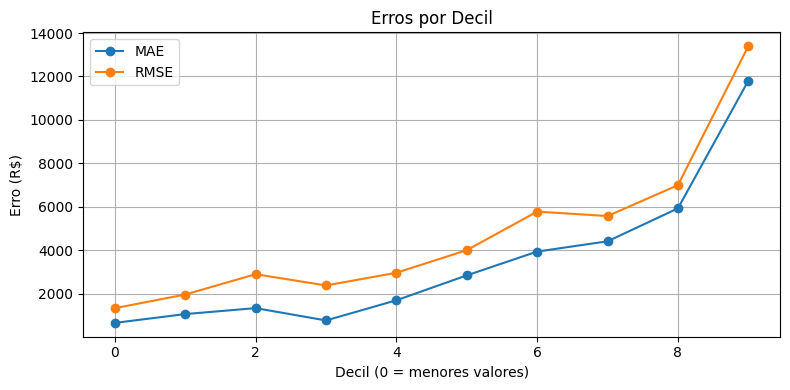

In [ ]:
# ERROS POR DECIL

df_errors = pd.DataFrame({'real': np.ravel(y_real), 'pred': np.ravel(pred_real)})
df_errors['decile'] = pd.qcut(df_errors['real'], 10, labels=False, duplicates='drop')

summary = df_errors.groupby('decile').apply(
    lambda g: pd.Series({
        'count': len(g),
        'MAE':  mean_absolute_error(g['real'], g['pred']),
        'RMSE': math.sqrt(mean_squared_error(g['real'], g['pred']))
    })
).reset_index()

print(summary)

plt.figure(figsize=(8, 4))
plt.plot(summary['decile'], summary['MAE'],  marker='o', label='MAE')
plt.plot(summary['decile'], summary['RMSE'], marker='o', label='RMSE')
plt.xlabel('Decil (0 = menores valores)')
plt.ylabel('Erro (R$)')
plt.title('Erros por Decil')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

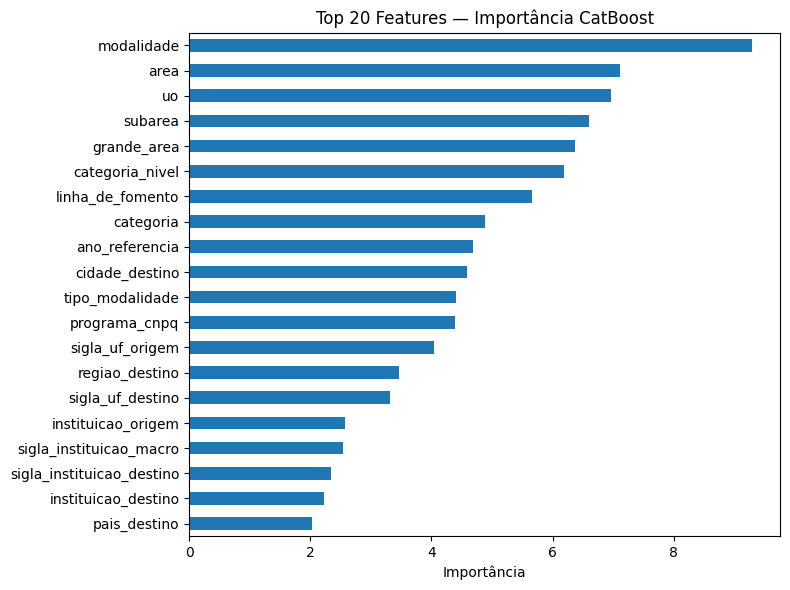

In [ ]:

# IMPORTÂNCIA DAS FEATURES

feat_imp = pd.Series(
    best_model.get_feature_importance(),
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
feat_imp.head(20).plot(kind='barh').invert_yaxis()
plt.title('Top 20 Features — Importância CatBoost')
plt.xlabel('Importância')
plt.tight_layout()
plt.show()

tipo_modalidade e categoria foram criados para resumir -> linha de fomento